In [ ]:
%load_ext autoreload
%autoreload 0

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# File Starts here

In [46]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy.random as rn
import os
import sys
import matplotlib.pyplot as plt

from circuit_extract import visualize_circuit_masks
from utils import *
import circuit_extract as ce
import inference
import train
import random
import colour_mnist

In [47]:
import utils as _utils
import importlib
from utils import *

def reload_utils():
    importlib.reload(_utils)
    globals().update(_utils.__dict__)
    
reload_utils()
importlib.reload(colour_mnist)
importlib.reload(train)


<module 'train' from '/home/cabbagepatch/Code/MI/vast/Mechanistic-Interpretability/train.py'>

In [48]:
os.makedirs("out", exist_ok=True)

In [49]:
import importlib

importlib.reload(inference)
importlib.reload(train)
importlib.reload(ce)

<module 'circuit_extract' from '/home/cabbagepatch/Code/MI/vast/Mechanistic-Interpretability/circuit_extract.py'>

In [4]:
def model_config(ds_name: str, lr: float, epochs: int, seed: int=0):
    return {
        "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        "seed": seed,
        "dataset": ds_name,
        "epochs": epochs, 
        "lr": lr,
    }

def circuit_config(ds_name: str, lr: float, cepochs: int, k_w: int, seed: int=0):
    return {
        "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        "seed": seed,
        "dataset": ds_name,
        "cepochs": cepochs, 
        "lr": lr,
        "k_w": k_w,
    }

In [5]:
seed_list = [102, 435, 860, 270, 106, 71, 700, 20, 201]

In [16]:
from colour_mnist import get_biased_mnist_dataloader


train_loader = get_biased_mnist_dataloader(
    root='./data',
    batch_size=64,
    data_label_correlation=0.99, # 99% of 0s are Red, 1s are Green, etc.
    train=True
)


test_loader = get_biased_mnist_dataloader(
    root='./data',
    batch_size=64,
    data_label_correlation=0.1,  # Colors are random
    train=False
)

In [17]:
# from random import choice



# X,Y,C = next(iter(train_loader))
# plt.imshow(choice(X).permute(1,2,0))

In [67]:
###Activation Patching Code###
from torch.utils.data import Subset, DataLoader

def cmnist(ds, colors, digits):
  
    mask = torch.isin(ds.labels, torch.tensor(digits)) & torch.isin(ds.biased_targets, torch.tensor(colors))
    idxs = mask.nonzero()
    subset = Subset(ds, indices=idxs)
    
    return DataLoader(
        subset, 
        batch_size=128, 
        shuffle=False, 
        pin_memory=True, 
        num_workers=4
    )

def activation_patching(src, dest, circuit: inference.Circuit):
    cache = circuit(src).cache
    
    current_act = dest
    
    for m, module in zip(circuit.masks, circuit.model.chain):
        current_act = module(current_act)
        patch_mask = (m.mask > 0).float()
        current_act = (patch_mask * cache[module]) + ((1 - patch_mask) * current_act)
    
    return current_act


def evaluate(loader, circuit, device, target_digit=0):
    circuit.eval()
    circuit.to(device)

    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, y, c in loader:
            x, y, c = x.to(device), y.to(device), c.to(device)

            src = x[(c == target_digit) & (y == target_digit)]
            dest = x[(c != target_digit) & (y == target_digit)]

            if len(src) == 0 or len(dest) == 0: continue

            minimum = min(len(src), len(dest)) 
            src = src[:minimum]
            dest = dest[:minimum]
    
            logits = activation_patching(src, dest, circuit)
                 
            predictions = logits.argmax(dim=1)
            correct += (predictions == target_digit).sum().item()
            total += minimum

    return correct / total if total > 0 else 0.0


In [68]:
seed_list = [102, 435, 860, 270, 106, 71, 700, 20, 201]

### Train Sparse Model ###

In [8]:
print("\n--- Phase 1: Initialize Model ---")
inp_shape = (3, 28, 28)
model = inference.CNN(nc=3, nf=16, num_classes=10, inp_shape=inp_shape)


--- Phase 1: Initialize Model ---


In [11]:
print("\n--- Phase 2: Train Sparse Baseline ---")
sched = scheduler(start = 2, end= 8, start_sparsity=1, target_sparsity=0.08, alpha=0.15)

# for i in range(55):
#     print(sched(i))

epochs = 12
ds = "colour-0.99"

cfg = model_config(ds_name='mnist', lr=1e-3, epochs=epochs)
device = cfg['device']
print(f"Running on {device}")

train_loader, test_loader = train.train_model(
    model=model,
    lr=cfg['lr'],
    b1=0.9, b2=0.999,
    scheduler = sched, 
    ds_name=ds,
    eps=1e-8,
    epochs=cfg['epochs'],
    device=device,
    seed=seed_list[0],
)


--- Phase 2: Train Sparse Baseline ---
Running on cpu
n_params 20720 n_params_wd 20720
cpu


KeyboardInterrupt: 

In [ ]:
print(f'CUDA available: {torch.cuda.is_available()}') 
print(f'Device count: {torch.cuda.device_count()}')
print(f'Current device: {torch.cuda.current_device() if torch.cuda.is_available() else None}')


CUDA available: True
Device count: 1
Current device: 0


In [ ]:
non_zero = sum([(p != 0).sum() for p in model.parameters()])
total = sum([p.numel() for p in model.parameters()])

print(f"{non_zero/total:.4f}")

0.0799


## Channeled MNIST to Coloured MNIST


### Training Model

In [18]:
print("\n--- Phase 1: Initialize Model ---")
inp_shape = (3, 28, 28)
model = inference.CNN(nc=3, nf=16, num_classes=10, inp_shape=inp_shape)


--- Phase 1: Initialize Model ---


In [ ]:
print("\n--- Phase 2: Train Sparse Baseline ---")
sched = scheduler(start = 2, end= 8, start_sparsity=1, target_sparsity=0.08, alpha=0.15)

epochs = 12

cfg = model_config(ds_name='channeled', lr=1e-3, epochs=epochs)
device = cfg['device']
print(f"Running on {device}")

train.train_model(
    model=model,
    lr=cfg['lr'],
    b1=0.9, b2=0.999,
    scheduler = sched, 
    ds_name=cfg['dataset'],
    eps=1e-8,
    epochs=cfg['epochs'],
    device=device,
    seed=seed_list[0]
)


--- Phase 2: Train Sparse Baseline ---
Running on cpu
n_params 20720 n_params_wd 20720
cpu
Epoch 0 | Train Acc: 0.9732 | Test Acc: 0.9736
Epoch 1 | Train Acc: 0.9815 | Test Acc: 0.9820
Epoch 2 | Train Acc: 0.9312 | Test Acc: 0.9343
Epoch 3 | Train Acc: 0.9457 | Test Acc: 0.9484
Epoch 4 | Train Acc: 0.9524 | Test Acc: 0.9547
Epoch 5 | Train Acc: 0.9591 | Test Acc: 0.9571
Epoch 6 | Train Acc: 0.9621 | Test Acc: 0.9629
Epoch 7 | Train Acc: 0.9543 | Test Acc: 0.9584
Epoch 8 | Train Acc: 0.9600 | Test Acc: 0.9587
Epoch 9 | Train Acc: 0.9612 | Test Acc: 0.9626
Epoch 10 | Train Acc: 0.9623 | Test Acc: 0.9642
Epoch 11 | Train Acc: 0.9659 | Test Acc: 0.9668


In [21]:
print(f'CUDA available: {torch.cuda.is_available()}') 
print(f'Device count: {torch.cuda.device_count()}')
print(f'Current device: {torch.cuda.current_device() if torch.cuda.is_available() else None}')


CUDA available: False
Device count: 0
Current device: None


In [22]:
non_zero = sum([(p != 0).sum() for p in model.parameters()])
total = sum([p.numel() for p in model.parameters()])

print(f"{non_zero/total:.4f}")

0.0799


### Circuit Extraction

In [54]:
trainloader, testloader = train.load_dataset("channeled")

In [55]:
X, Y = next(iter(trainloader))
X.shape

torch.Size([128, 3, 28, 28])

In [56]:
classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
circuits = {}

lr=1e-1
l0_lambda=5e+1
mean_ablation=True
seed = seed_list[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs=1

for cls in classes:
    ds_name = f"channeled-class-{cls}"
    mean_ablation_ds = "channeled"

    circuit = train.extract_circuit(
        model=deepcopy(model),
        lr=lr,
        b1=0.9, b2=0.999,
        ds_name=ds_name,     
        eps=1e-8,
        epochs=epochs,
        device=device,
        l0_lambda=l0_lambda,
        seed=seed,
        mean_ablation=mean_ablation,
        mean_ablation_dataset=mean_ablation_ds
    )

    circuits[cls] = circuit

print("Done")

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.1974 | Avg Mask: -0.964 | Total Non-Zero: 288.0 | | Circuit Acc: 0.9764
Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 11.4995 | Avg Mask: -0.937 | Total Non-Zero: 498.0 | | Circuit Acc: 0.9570
Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.6345 | Avg Mask: -0.959 | Total Non-Zero: 363.0 | | Circuit Acc: 0.9946
Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.5828 | Avg Mask: -0.959 | Total Non-Zero: 370.0 | | Circuit Acc: 0.9930
Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.8268 | Avg M

0


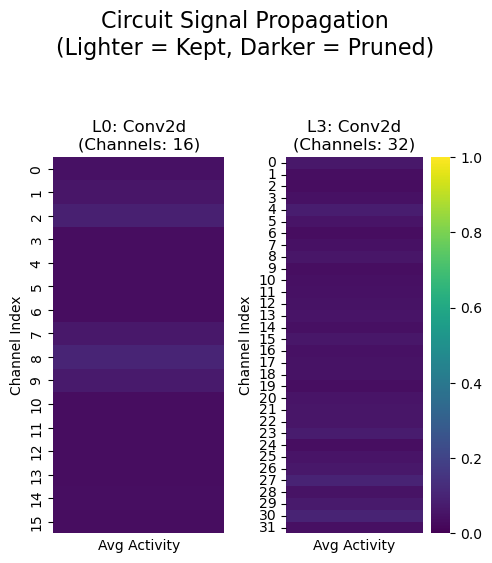


Visualization saved to out/circuit_visualization.png
1


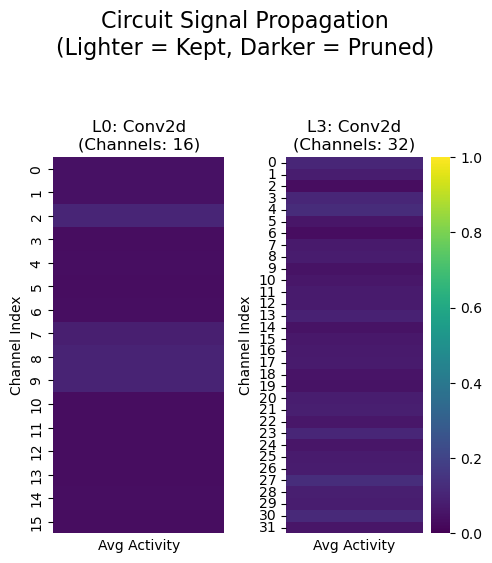


Visualization saved to out/circuit_visualization.png
2


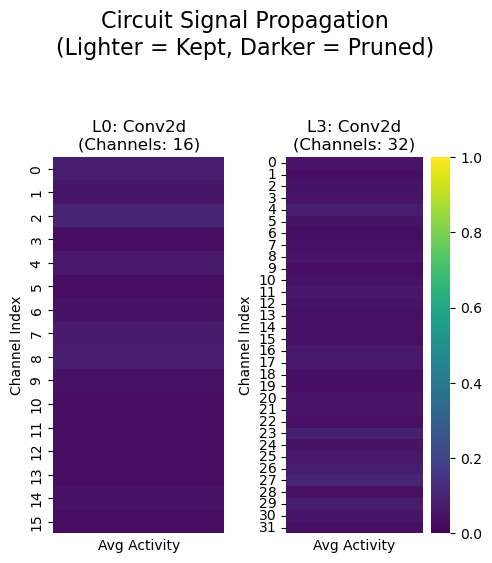


Visualization saved to out/circuit_visualization.png
3


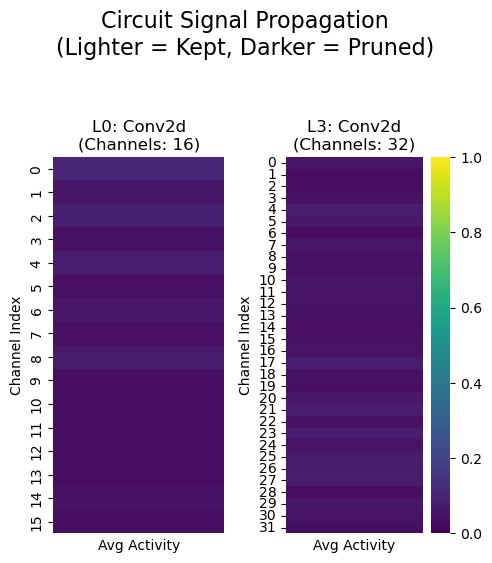


Visualization saved to out/circuit_visualization.png
4


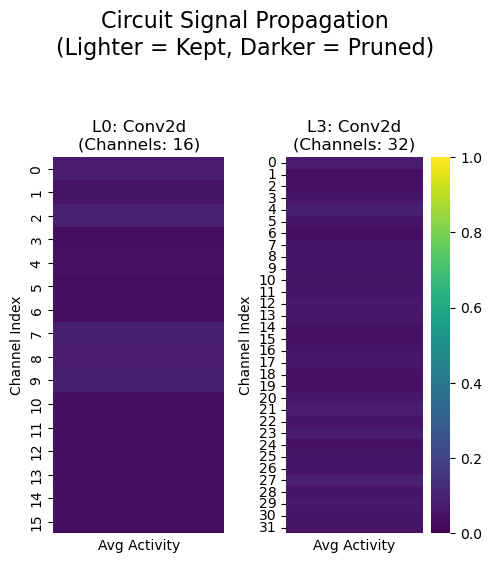


Visualization saved to out/circuit_visualization.png
5


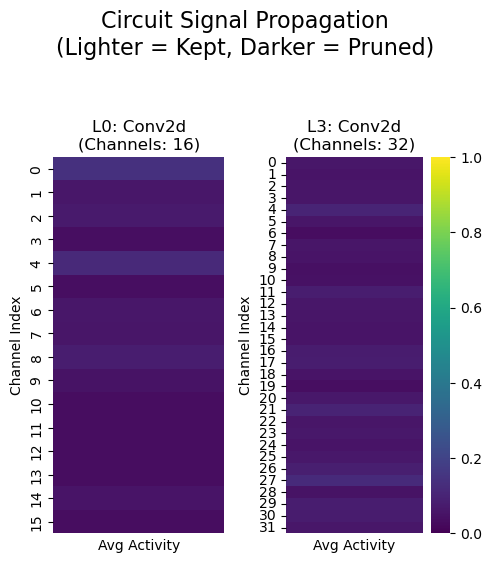


Visualization saved to out/circuit_visualization.png
6


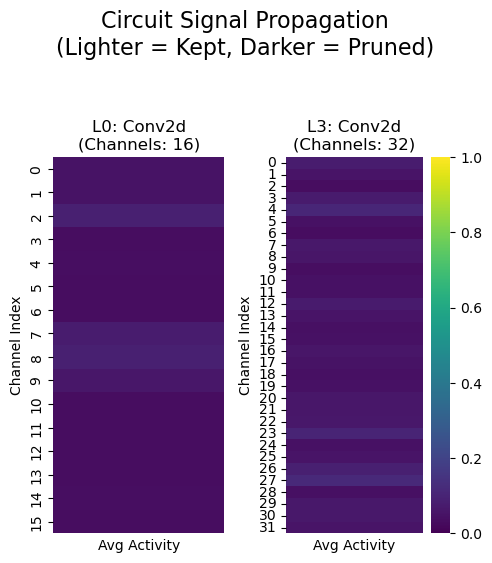


Visualization saved to out/circuit_visualization.png
7


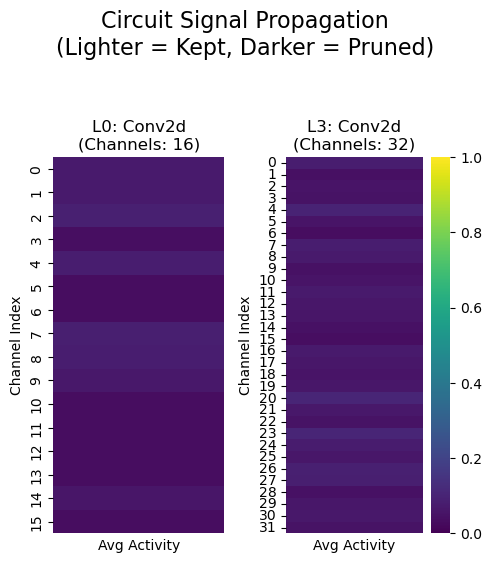


Visualization saved to out/circuit_visualization.png
8


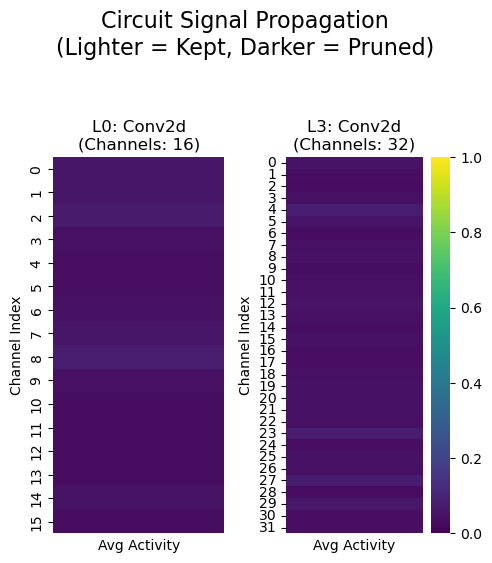


Visualization saved to out/circuit_visualization.png
9


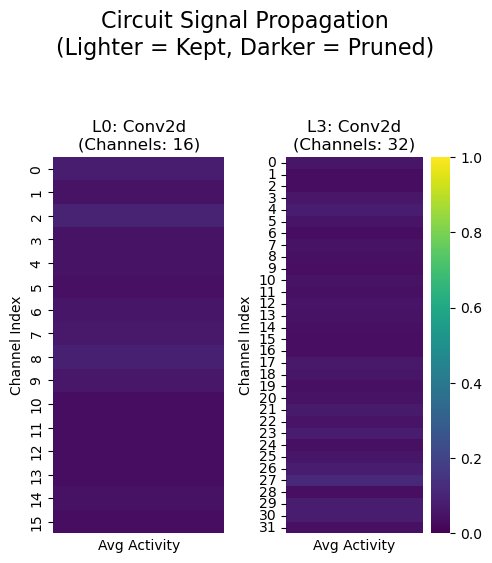


Visualization saved to out/circuit_visualization.png


In [57]:
for k,v in circuits.items():
    print(k)
    visualize_circuit_masks(v)

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


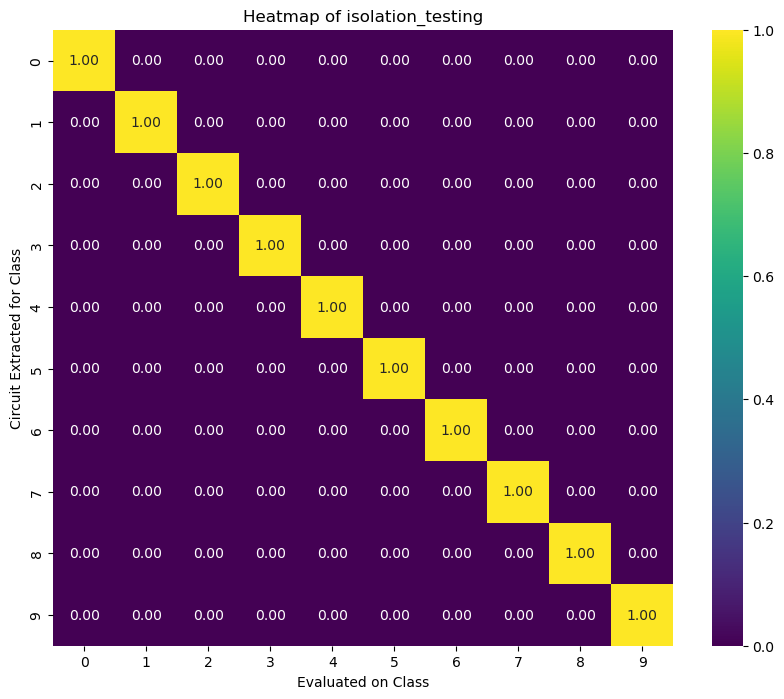

In [58]:
iso_heatmap = plot_circuit_testing_heatmap(
    circuits_dict=circuits,
    test_func=isolation_testing,
    dataloader=testloader,
    dev=device
)
plt.show()

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


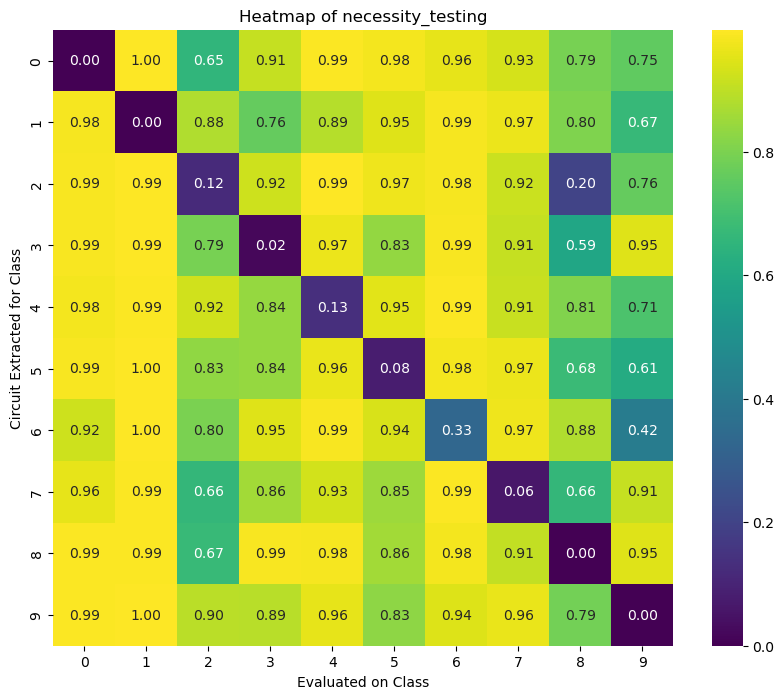

In [59]:
nec_heatmap = plot_circuit_testing_heatmap(
    circuits_dict=circuits,
    test_func=necessity_testing,
    dataloader=testloader,
    dev=device
)
plt.show()

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


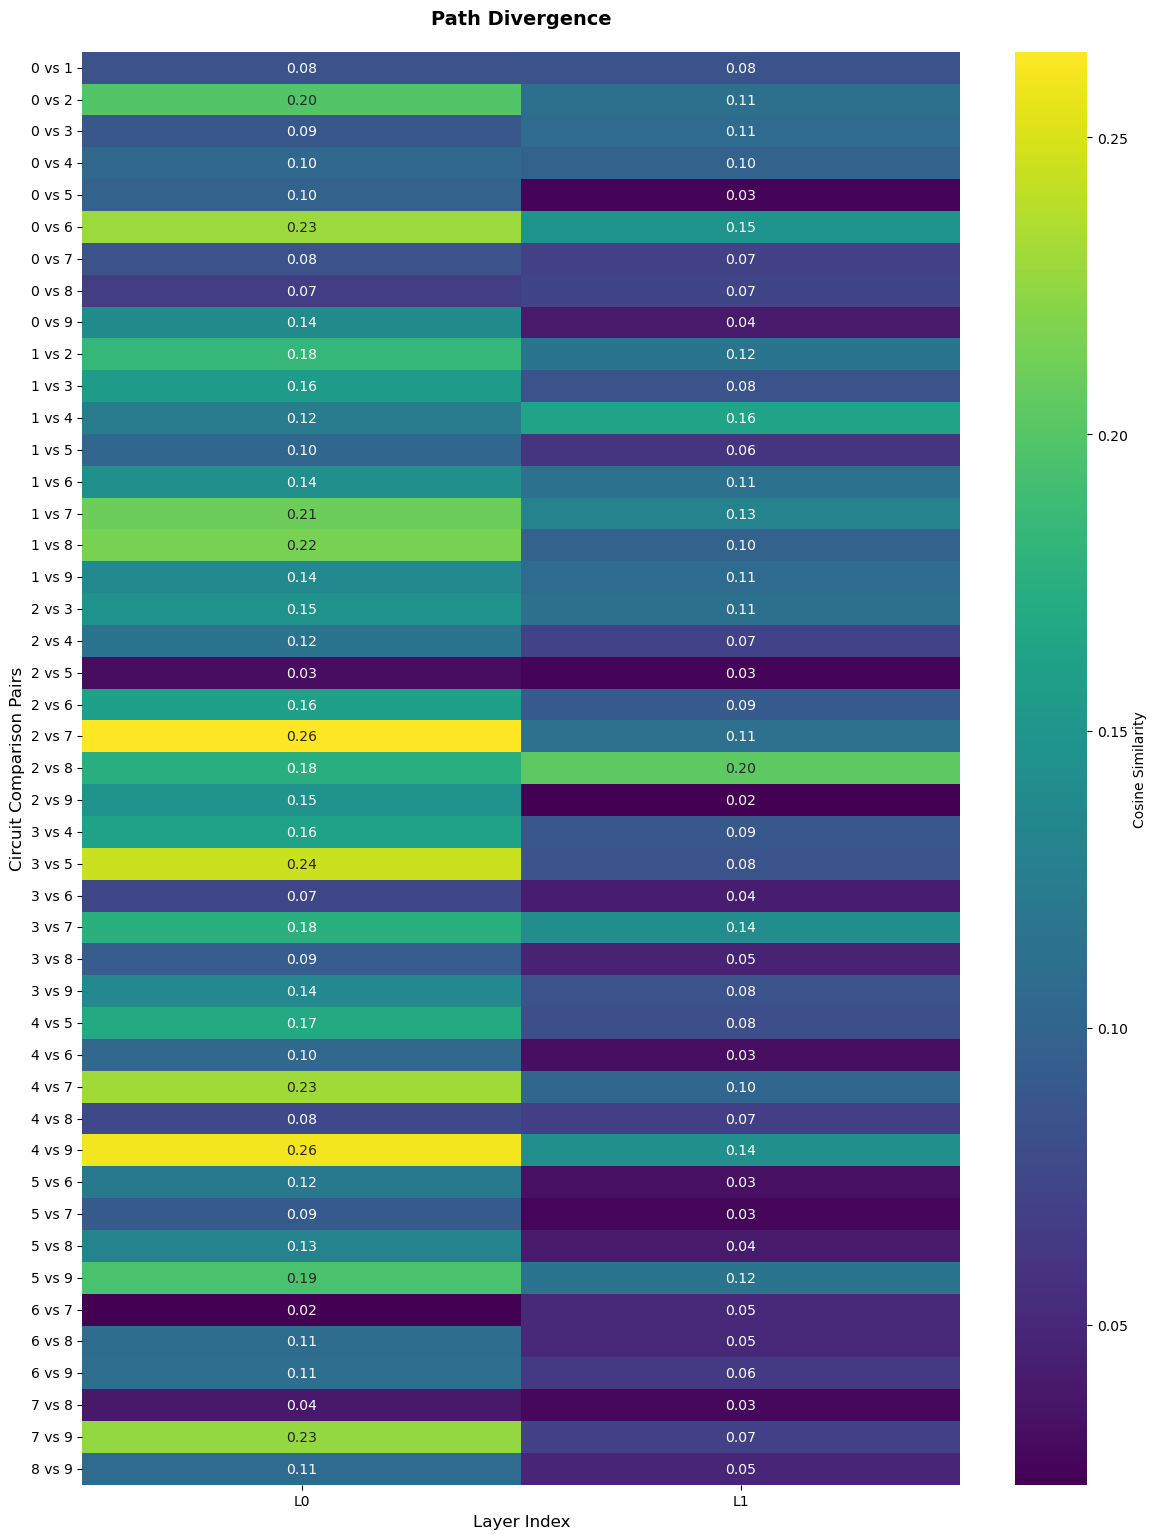

In [60]:
divergence_results = path_divergence_dict(
    circuits_dict=circuits,
    loader=trainloader,
    device=device
)

plot_path_divergence_trajectories(divergence_results, 'out/path_div_trajectory.png', title='Path Divergence')

### Cross-Modal

In [70]:
trainloader, testloader = train.load_dataset("colour-0.1")

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [71]:
X, Y = next(iter(trainloader))
X.shape

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


torch.Size([128, 3, 28, 28])

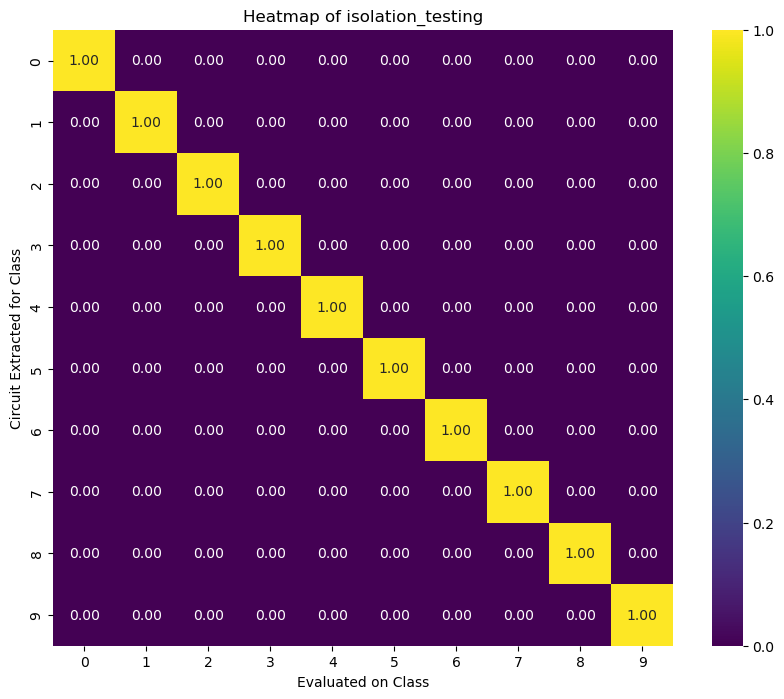

In [72]:
iso_heatmap = plot_circuit_testing_heatmap(
    circuits_dict=circuits,
    test_func=isolation_testing,
    dataloader=testloader,
    dev=device
)
plt.show()

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


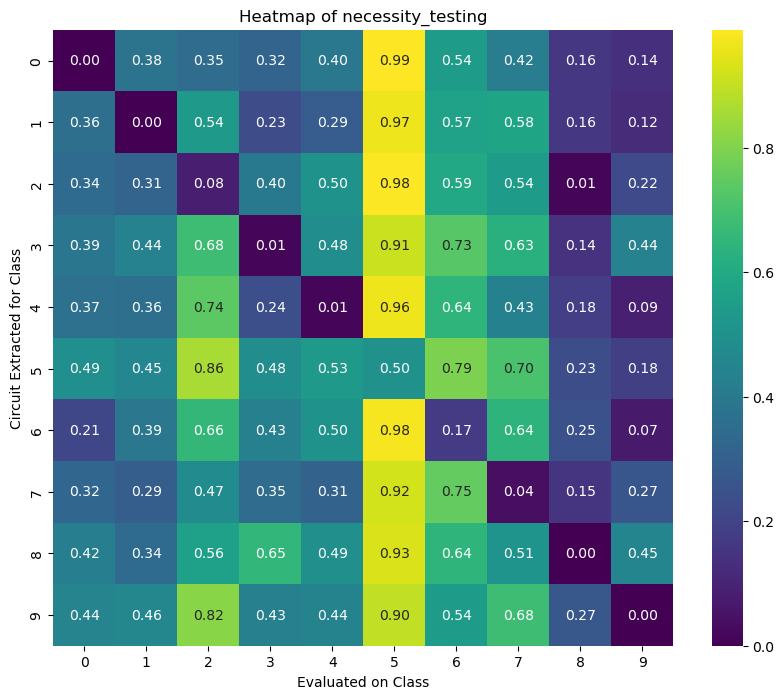

In [73]:
nec_heatmap = plot_circuit_testing_heatmap(
    circuits_dict=circuits,
    test_func=necessity_testing,
    dataloader=testloader,
    dev=device
)
plt.show()

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


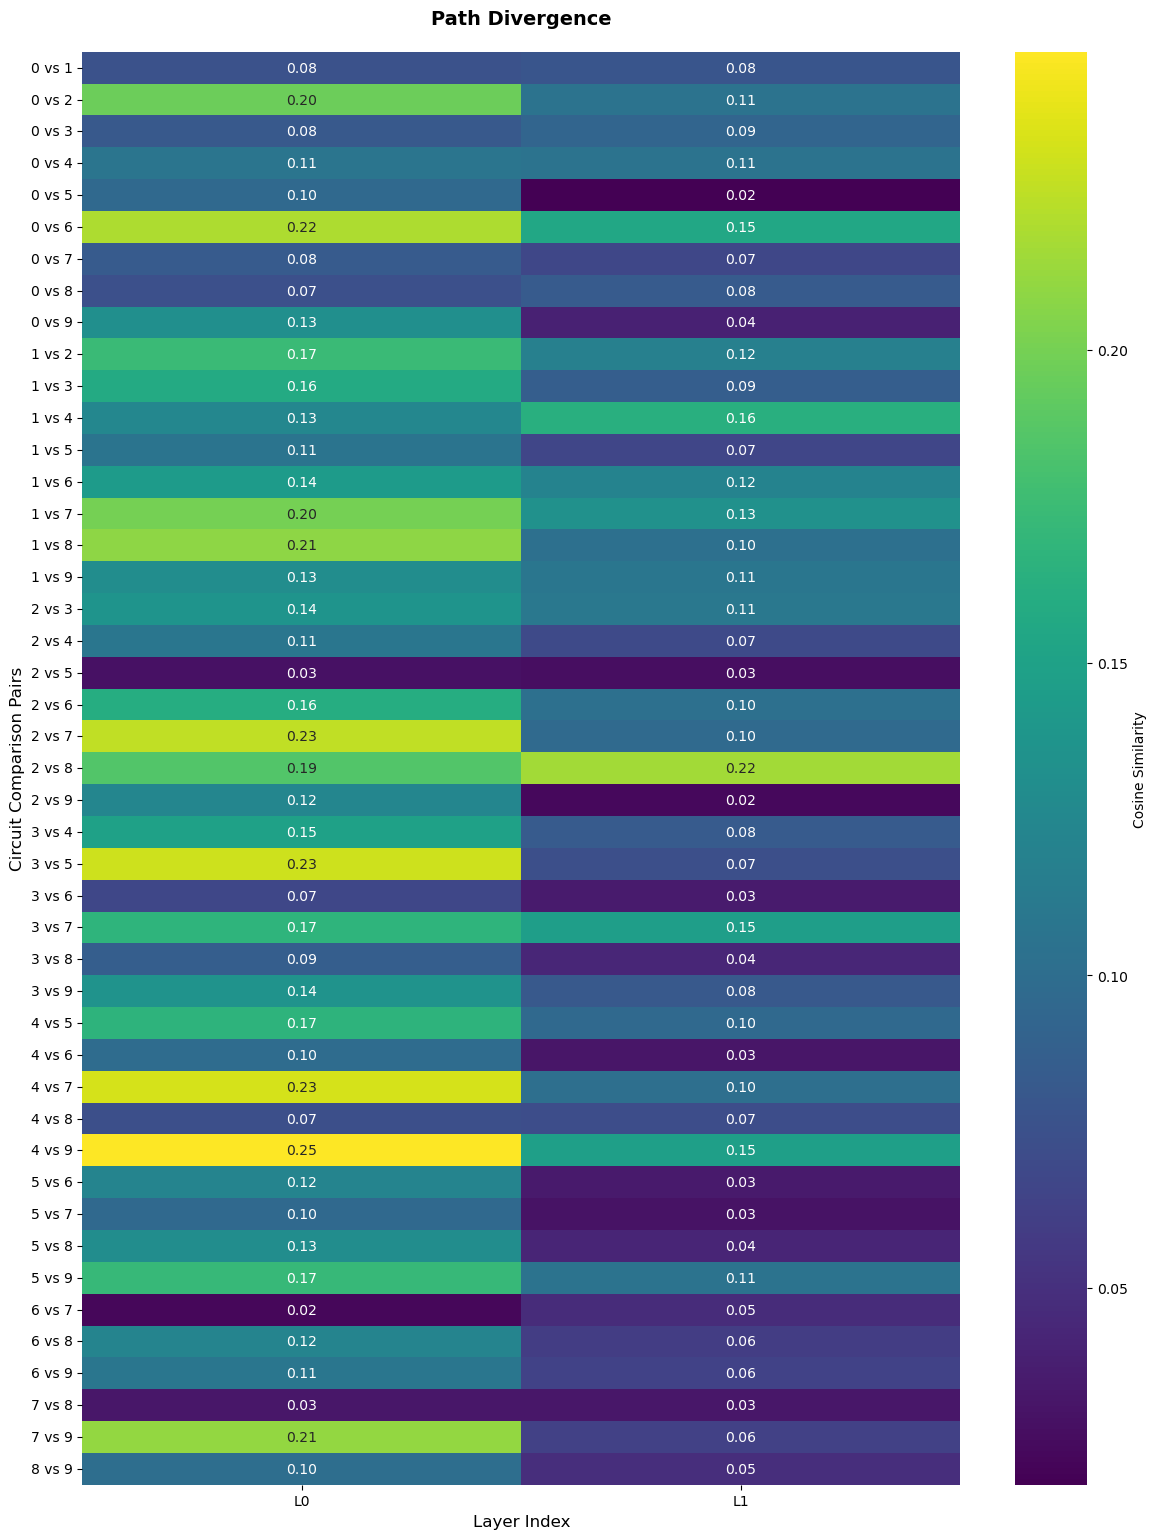

In [74]:
divergence_results = path_divergence_dict(
    circuits_dict=circuits,
    loader=trainloader,
    device=device
)

plot_path_divergence_trajectories(divergence_results, 'out/path_div_trajectory.png', title='Path Divergence')

In [77]:
torch.save(model.state_dict(),("channeled_model"))

## Coloured MNIST to Channeled MNIST


### Training Model

In [102]:
print("\n--- Phase 1: Initialize Model ---")
inp_shape = (3, 28, 28)
model = inference.CNN(nc=3, nf=16, num_classes=10, inp_shape=inp_shape)


--- Phase 1: Initialize Model ---


In [103]:
print("\n--- Phase 2: Train Sparse Baseline ---")
sched = scheduler(start = 2, end= 8, start_sparsity=1, target_sparsity=0.08, alpha=0.15)

epochs = 12

cfg = model_config(ds_name='colour-1.0', lr=1e-3, epochs=epochs)
device = cfg['device']
print(f"Running on {device}")

train.train_model(
    model=model,
    lr=cfg['lr'],
    b1=0.9, b2=0.999,
    scheduler = sched, 
    ds_name=cfg['dataset'],
    eps=1e-8,
    epochs=cfg['epochs'],
    device=device,
    seed=seed_list[0]
)


--- Phase 2: Train Sparse Baseline ---
Running on cpu


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


n_params 20720 n_params_wd 20720
cpu


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 0 | Train Acc: 1.0000 | Test Acc: 1.0000
Epoch 1 | Train Acc: 1.0000 | Test Acc: 1.0000
Epoch 2 | Train Acc: 0.9998 | Test Acc: 0.9998
Epoch 3 | Train Acc: 1.0000 | Test Acc: 1.0000
Epoch 4 | Train Acc: 1.0000 | Test Acc: 1.0000
Epoch 5 | Train Acc: 1.0000 | Test Acc: 1.0000
Epoch 6 | Train Acc: 1.0000 | Test Acc: 1.0000
Epoch 7 | Train Acc: 1.0000 | Test Acc: 1.0000
Epoch 8 | Train Acc: 1.0000 | Test Acc: 1.0000
Epoch 9 | Train Acc: 1.0000 | Test Acc: 1.0000
Epoch 10 | Train Acc: 1.0000 | Test Acc: 1.0000
Epoch 11 | Train Acc: 1.0000 | Test Acc: 1.0000


In [123]:
torch.save(model.state_dict(), "coloured_model")

In [126]:
st = torch.load("coloured_model", weights_only=True)
model.load_state_dict(st)

<All keys matched successfully>

In [127]:
print(f'CUDA available: {torch.cuda.is_available()}') 
print(f'Device count: {torch.cuda.device_count()}')
print(f'Current device: {torch.cuda.current_device() if torch.cuda.is_available() else None}')


CUDA available: False
Device count: 0
Current device: None


In [128]:
non_zero = sum([(p != 0).sum() for p in model.parameters()])
total = sum([p.numel() for p in model.parameters()])

print(f"{non_zero/total:.4f}")

0.0799


### Circuit Extraction

In [129]:
trainloader, testloader = train.load_dataset("colour-1.0")

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [130]:
X, Y = next(iter(trainloader))
X.shape

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


torch.Size([128, 3, 28, 28])

In [132]:
classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
circuits = {}

lr=1e-1
l0_lambda=5e+1
mean_ablation=True
seed = seed_list[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs=2

for cls in classes:
    ds_name = f"colour-1.0-class-{cls}"
    mean_ablation_ds = "colour-1.0"

    circuit = train.extract_circuit(
        model=deepcopy(model),
        lr=lr,
        b1=0.9, b2=0.999,
        ds_name=ds_name,     
        eps=1e-8,
        epochs=epochs,
        device=device,
        l0_lambda=l0_lambda,
        seed=seed,
        mean_ablation=mean_ablation,
        mean_ablation_dataset=mean_ablation_ds
    )

    circuits[cls] = circuit

print("Done")

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.2203 | Avg Mask: -0.959 | Total Non-Zero: 342.0 | | Circuit Acc: 1.0000
Epoch 1 | Loss: 0.8046 | Avg Mask: -0.966 | Total Non-Zero: 238.0 | | Circuit Acc: 1.0000
Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 10.3694 | Avg Mask: -0.978 | Total Non-Zero: 178.0 | | Circuit Acc: 1.0000
Epoch 1 | Loss: 0.5327 | Avg Mask: -0.978 | Total Non-Zero: 184.0 | | Circuit Acc: 1.0000
Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 11.7382 | Avg Mask: -0.976 | Total Non-Zero: 173.0 | | Circuit Acc: 1.0000
Epoch 1 | Loss: 0.4398 | Avg Mask: -0.980 | Total Non-Zero: 135.0 | | Circuit Acc: 1.0000
Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting C

0


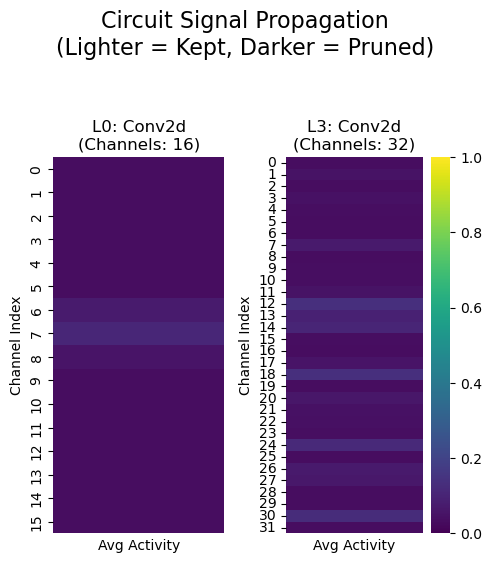


Visualization saved to out/circuit_visualization.png
1


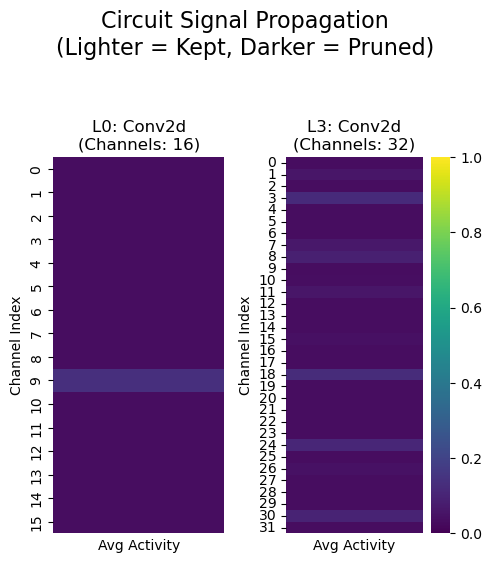


Visualization saved to out/circuit_visualization.png
2


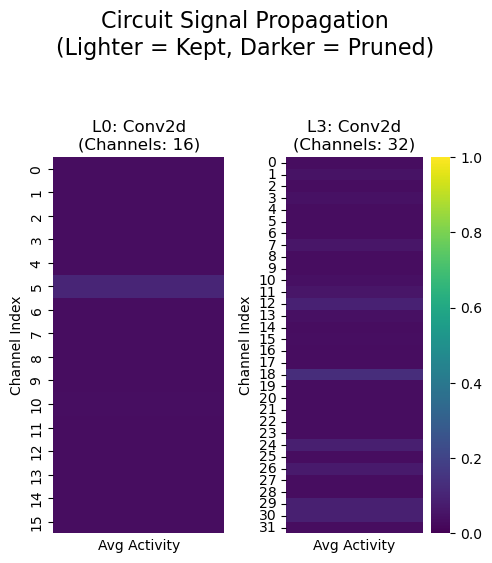


Visualization saved to out/circuit_visualization.png
3


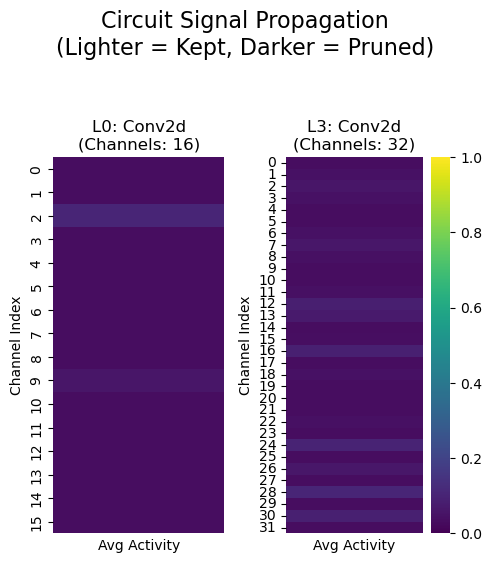


Visualization saved to out/circuit_visualization.png
4


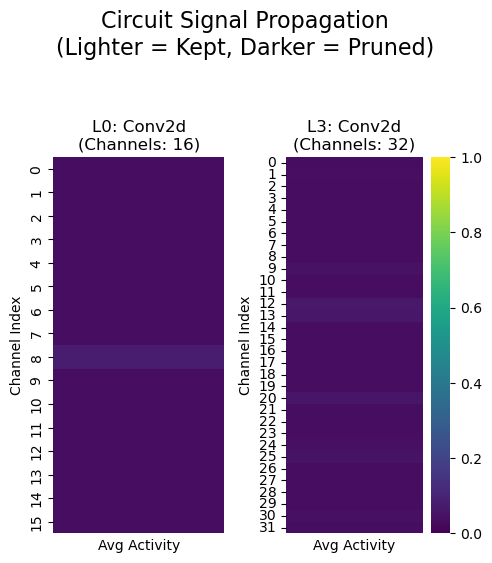


Visualization saved to out/circuit_visualization.png
5


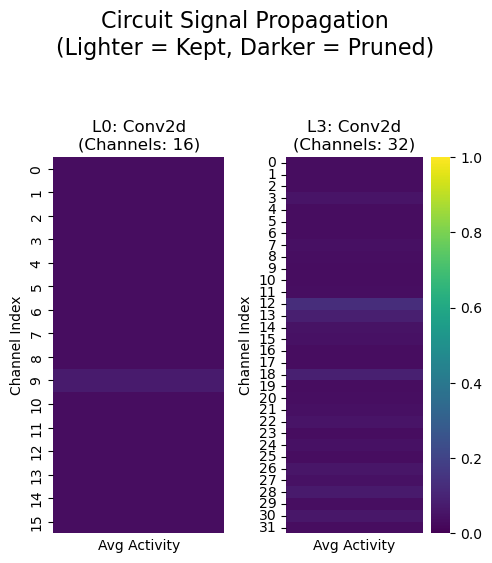


Visualization saved to out/circuit_visualization.png
6


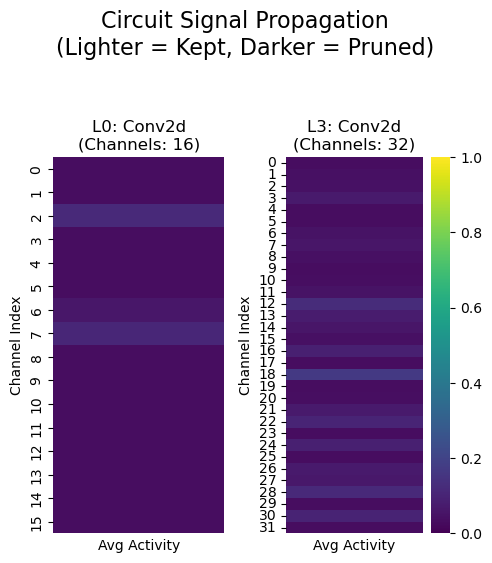


Visualization saved to out/circuit_visualization.png
7


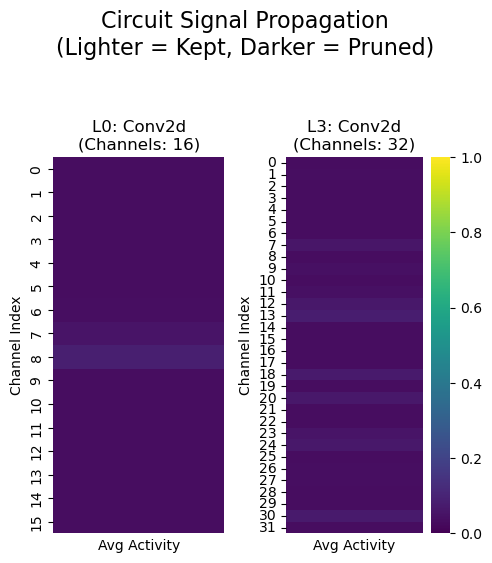


Visualization saved to out/circuit_visualization.png
8


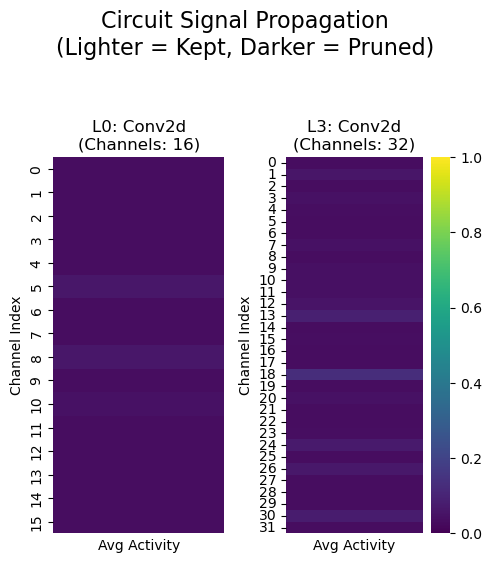


Visualization saved to out/circuit_visualization.png
9


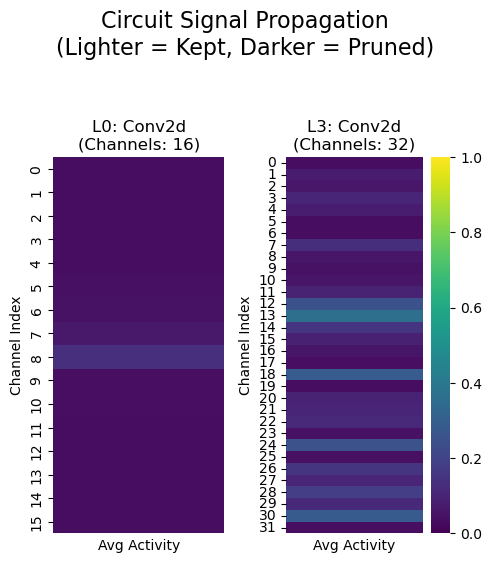


Visualization saved to out/circuit_visualization.png


In [133]:
for k,v in circuits.items():
    print(k)
    visualize_circuit_masks(v)

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


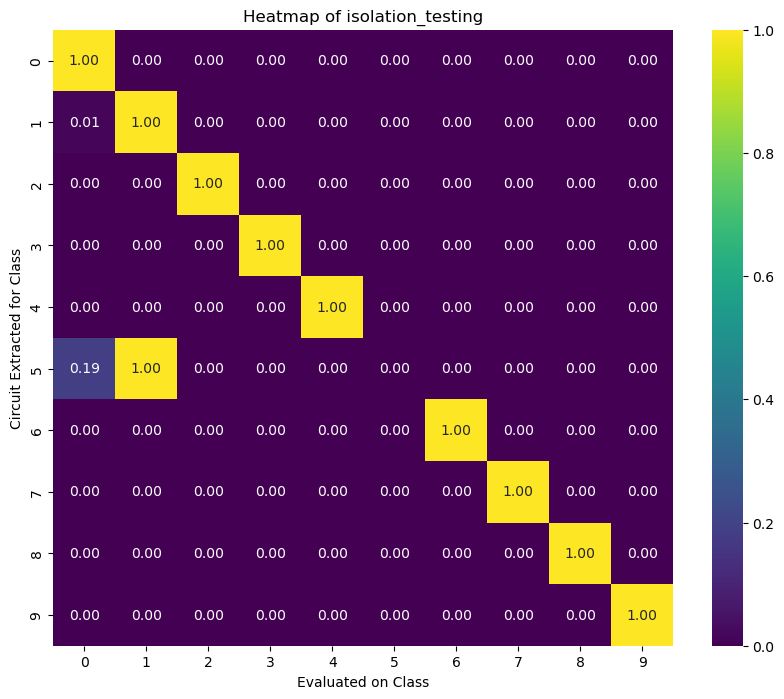

In [134]:
iso_heatmap = plot_circuit_testing_heatmap(
    circuits_dict=circuits,
    test_func=isolation_testing,
    dataloader=testloader,
    dev=device
)
plt.show()

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


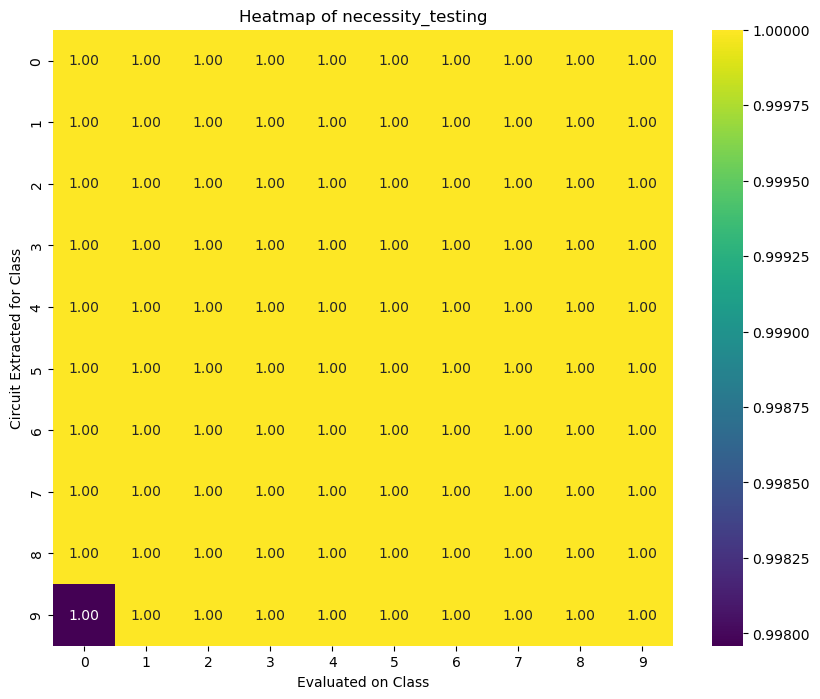

In [135]:
nec_heatmap = plot_circuit_testing_heatmap(
    circuits_dict=circuits,
    test_func=necessity_testing,
    dataloader=testloader,
    dev=device
)
plt.show()

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


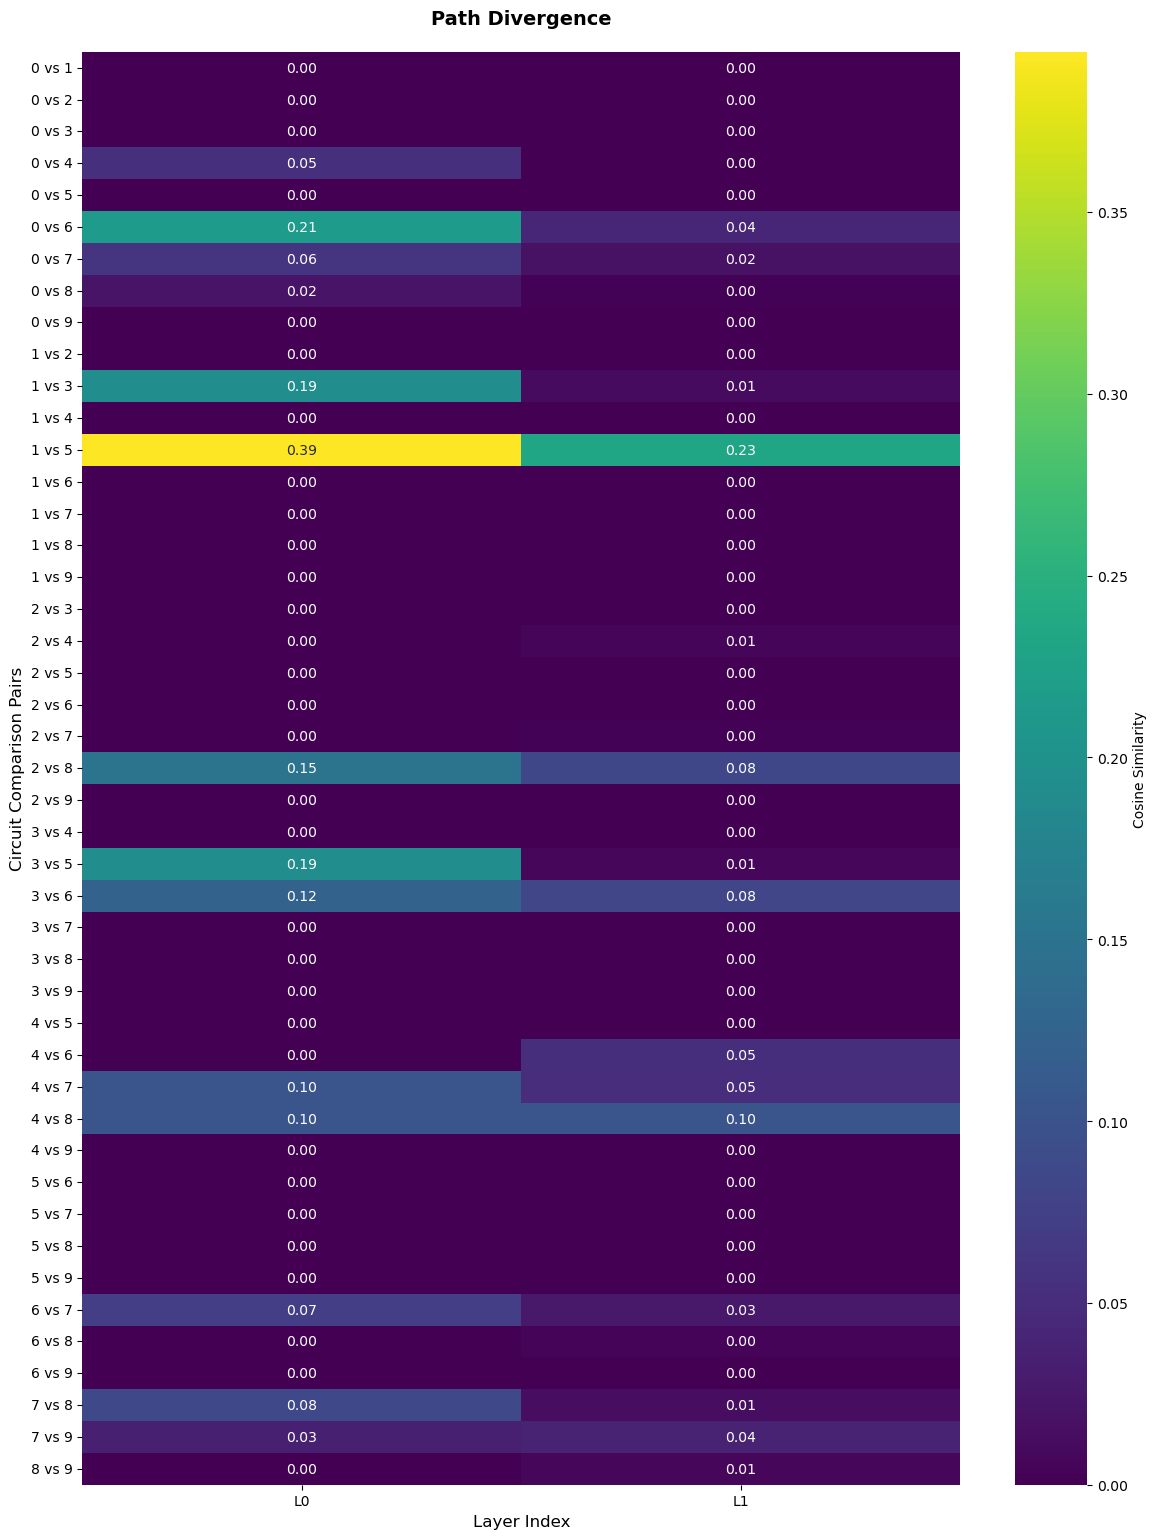

In [136]:
divergence_results = path_divergence_dict(
    circuits_dict=circuits,
    loader=trainloader,
    device=device
)

plot_path_divergence_trajectories(divergence_results, 'out/path_div_trajectory.png', title='Path Divergence')

### Cross-Modal

In [137]:
trainloader, testloader = train.load_dataset("channeled")

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [138]:
X, Y = next(iter(trainloader))
X.shape

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


torch.Size([128, 3, 28, 28])

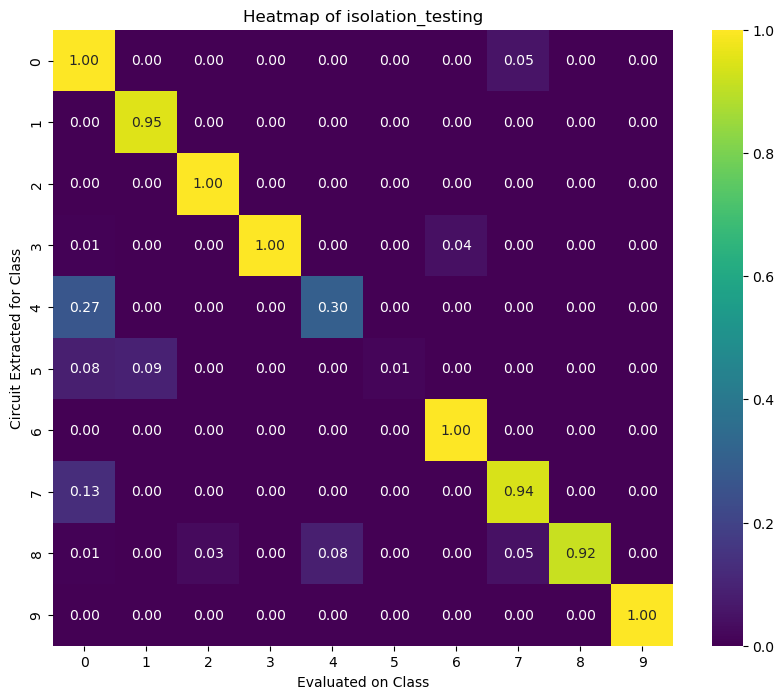

In [139]:
iso_heatmap = plot_circuit_testing_heatmap(
    circuits_dict=circuits,
    test_func=isolation_testing,
    dataloader=testloader,
    dev=device
)
plt.show()

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


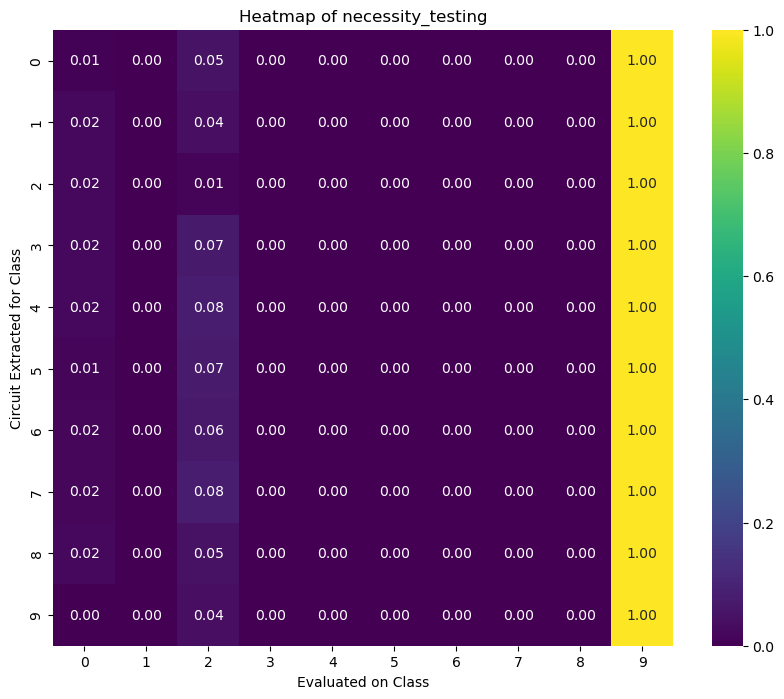

In [140]:
nec_heatmap = plot_circuit_testing_heatmap(
    circuits_dict=circuits,
    test_func=necessity_testing,
    dataloader=testloader,
    dev=device
)
plt.show()

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


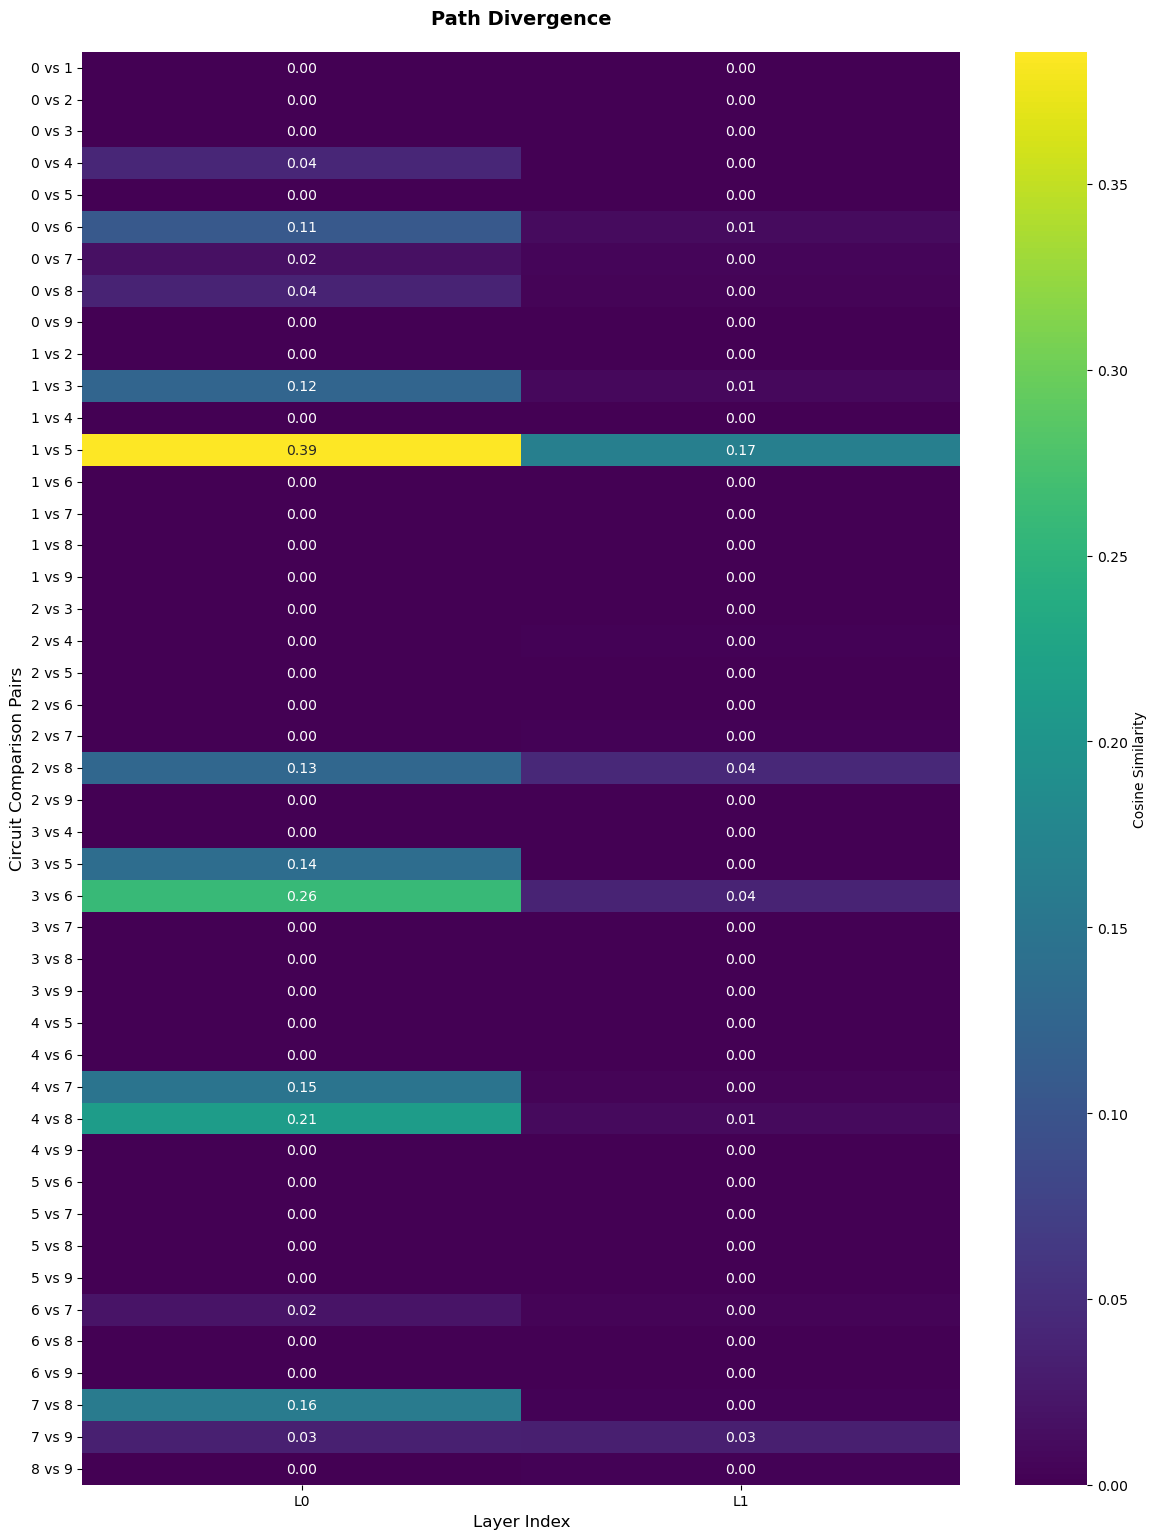

In [141]:
divergence_results = path_divergence_dict(
    circuits_dict=circuits,
    loader=trainloader,
    device=device
)

plot_path_divergence_trajectories(divergence_results, 'out/path_div_trajectory.png', title='Path Divergence')

In [75]:
n_model_config = {
    'lr': 1e-3, 'epochs': 12, 'ds_name': 'color-1', 
    'device': 'cpu', 'seed': seed_list[3], 'inp_shape': (3, 28, 28), 'num_classes': 10
}
sched = scheduler(start = 2, end= 8, start_sparsity=1, target_sparsity=0.08, alpha=0.15)

In [ ]:
color_config = n_model_config.copy()
color_config['ds_name'] = 'colour-1'
color_config['seed'] = seed_list[5]
color_config['inp_shape'] = (3, 28, 28)

In [ ]:
color_config

{'lr': 0.001,
 'epochs': 12,
 'ds_name': 'colour-mnist',
 'device': 'cuda',
 'seed': 71,
 'inp_shape': (3, 28, 28),
 'num_classes': 10}

In [ ]:
colored_model = train_n_models(1, color_config, sched)[0]

n_params 20720 n_params_wd 20720
cuda
Epoch 0 | Train Acc: 0.9929 | Test Acc: 0.9904
Epoch 1 | Train Acc: 0.9949 | Test Acc: 0.9935
Epoch 2 | Train Acc: 0.9898 | Test Acc: 0.9893
Epoch 3 | Train Acc: 0.9893 | Test Acc: 0.9878
Epoch 4 | Train Acc: 0.9915 | Test Acc: 0.9903
Epoch 5 | Train Acc: 0.9921 | Test Acc: 0.9911
Epoch 6 | Train Acc: 0.9925 | Test Acc: 0.9910
Epoch 7 | Train Acc: 0.9920 | Test Acc: 0.9900
Epoch 8 | Train Acc: 0.9922 | Test Acc: 0.9904
Epoch 9 | Train Acc: 0.9920 | Test Acc: 0.9903
Epoch 10 | Train Acc: 0.9922 | Test Acc: 0.9909
Epoch 11 | Train Acc: 0.9929 | Test Acc: 0.9915


In [ ]:
color_train, color_test = train.load_dataset("colour-mnist")

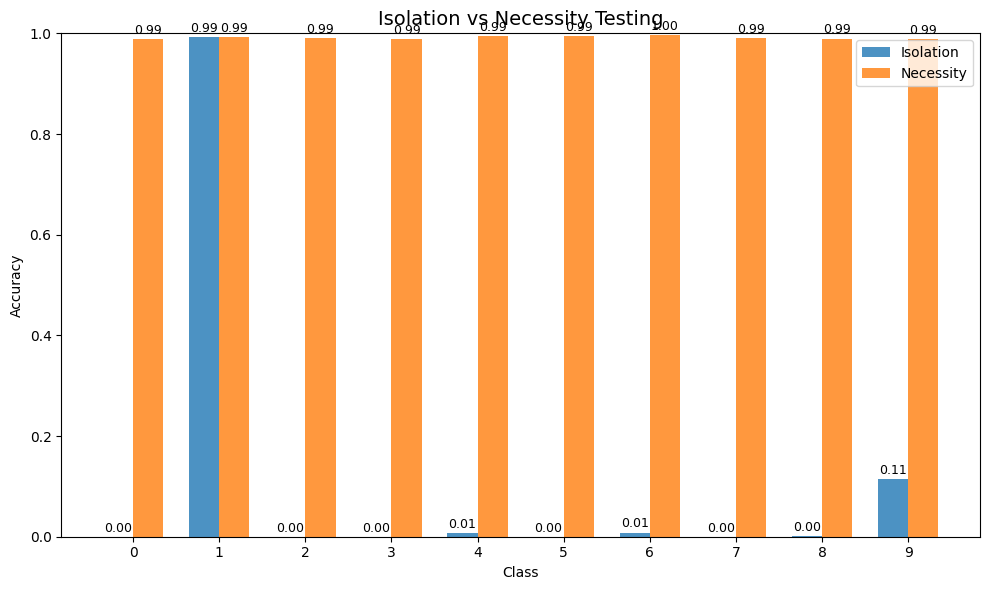

In [ ]:
mnist_to_color_results = cross_model_circuit_test(
    src_model=best_mnist_model, 
    target_model=colored_model, 
    target_loader=color_test, 
    class_idx=TARGET_TEST_CLASS, 
    src_circuit=best_mnist_circuit, 
    dev=DEVICE,
    seed=seed_list[6]
)

In [ ]:
color_to_mnist_results = cross_model_circuit_test(
    src_model=colored_model, 
    target_model=best_mnist_model, 
    target_loader=mnist_test, 
    class_idx=TARGET_TEST_CLASS, 
    src_circuit=None, # Will extract automatically
    dev=DEVICE,
    seed=seed_list[7],
    colour=
)

Extracting source circuit for class 3...
 Processing Class 3 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-3
Calculating mean activations...


RuntimeError: Given groups=1, weight of size [16, 3, 3, 3], expected input[1, 1, 28, 28] to have 3 channels, but got 1 channels instead